# Cookie cats A/B test

This notebook presents the code written to perform the A/B testing analysis for the cookie cats game dataset.  
As specified in the dataset information we have, for each user, the group it belongs to (version with gate at level 30 vs level 40), its retention (within the first and the first seven days of playing the game) and the total gamerounds it has initiated.

First of all, let's import all necessary libraries and read the case data

In [ ]:
import os
import dotenv
import kagglehub
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chisquare, norm
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

In [24]:
def read_data():
    data_dir = "./mobile_games"
    os.makedirs(data_dir, exist_ok = True)
    try:
        data = pd.read_csv(f"{data_dir}/cookie_cats.csv")
    except FileNotFoundError:
        # Download from Kaggle and save to data directory
        dotenv.load_dotenv(dotenv.find_dotenv())
        kagglehub.login()
        kagglehub.dataset_download("yufengsui/mobile-games-ab-testing",
                                   output_dir = data_dir,
                                   force_download = True)
        data = pd.read_csv(f"{data_dir}/cookie_cats.csv")
        data.to_csv(f"{data_dir}/cookie_cats.csv", index = False)
        
        # # Clean up downloaded files
        base_dir = Path.cwd().resolve().parent / "wx_kaggle_notebooks/mobile_games"
        print(base_dir)
        targets = [base_dir / ".complete"]

        for target in targets:
            if target.is_dir():
                shutil.rmtree(target)
            elif target.exists():
                target.unlink()
            else:
                print(f"Not found: {target}")
    data.columns = data.columns.str.lower()
    for col in ["retention_1", "retention_7"]:
        data[col] = data[col].astype(int)
    return data

data = read_data()

## 0. Data Preprocessing

Basically removing outliers and performing other simple checks

### 0.1. Removing outliers

On a preliminary analysis it was seen an outlier value on the control distribution which showed a huge amount of played rounds. We'll remove this record from the dataset since it doesn't represent the nature of the rest of the data.

In [25]:
outlier = data[data["sum_gamerounds"] >= 10000]
print(f"Rounds played by outliers: {outlier['sum_gamerounds'].tolist()}")
data = data[data["sum_gamerounds"] < 10000]

Rounds played by outliers: [49854]


### 0.2. Initial checks

In [26]:
# Null values
print(f"Are there null values in the dataset? --> {data.isnull().sum().any()}")
# Duplicate ids
print(f"Are there duplicate userids? --> {data['userid'].duplicated().any()}")

Are there null values in the dataset? --> False
Are there duplicate userids? --> False


## 1. Sample Ratio Mismatch

Since some info has been removed from the dataset (outliers), and also as a normal procedure, we'll check if both groups have an equal split between each other.

In [27]:
print("Proportion of users in each version:")
print(
    (data.groupby("version")["userid"].nunique() / data["userid"].nunique()).to_frame().to_records()
)

Proportion of users in each version:
[('gate_30', 0.49562026) ('gate_40', 0.50437974)]


Percentage of users in each group (percentage) looks almost identical, so it appears to be no hints of wrong sampling procedures during the A/B test.  
Still, we'll double-check by running a Chi-Square test on the observed frequencies:

In [28]:
srm_alpha = 0.001
observed = data.groupby(["version"])["userid"].nunique().tolist()
expected = [sum(observed) / len(observed)] * len(observed)
_, p_value = chisquare(f_obs = observed, f_exp = expected)
if p_value < srm_alpha:
    print(f"The groups are not equally distributed (p = {p_value:.4f} < {srm_alpha})")
else:
    print(f"The groups are equally distributed (p = {p_value:.4f} >= {srm_alpha})")
del observed, expected, p_value, srm_alpha

The groups are equally distributed (p = 0.0085 >= 0.001)


## Framing: primary metric vs. guardrail

Depending on the business priority, the two metrics can swap roles:

* **Retention as primary, game rounds as guardrail** — if the goal is long-term engagement, optimize for 1-day and 7-day retention, and use game rounds to ensure the winning gate placement doesn't tank actual playtime.

* **Game rounds as primary, retention as guardrail** — if the focus is ad revenue driven by raw playtime, optimize for game rounds and use retention to check that any short-term engagement spike doesn't cause players to burn out and churn long-term.

This dataset illustrates why the guardrail matters: 1-day retention shows little difference between gate placements, but a clear gap opens at 7 days. Ignoring 7-day retention would risk mistaking the gate_40 result as neutral or even positive.

## 2. Analysis

Let's go over the main variables, game rounds and retention, split by the test groups.

### 2.1. Retention rates

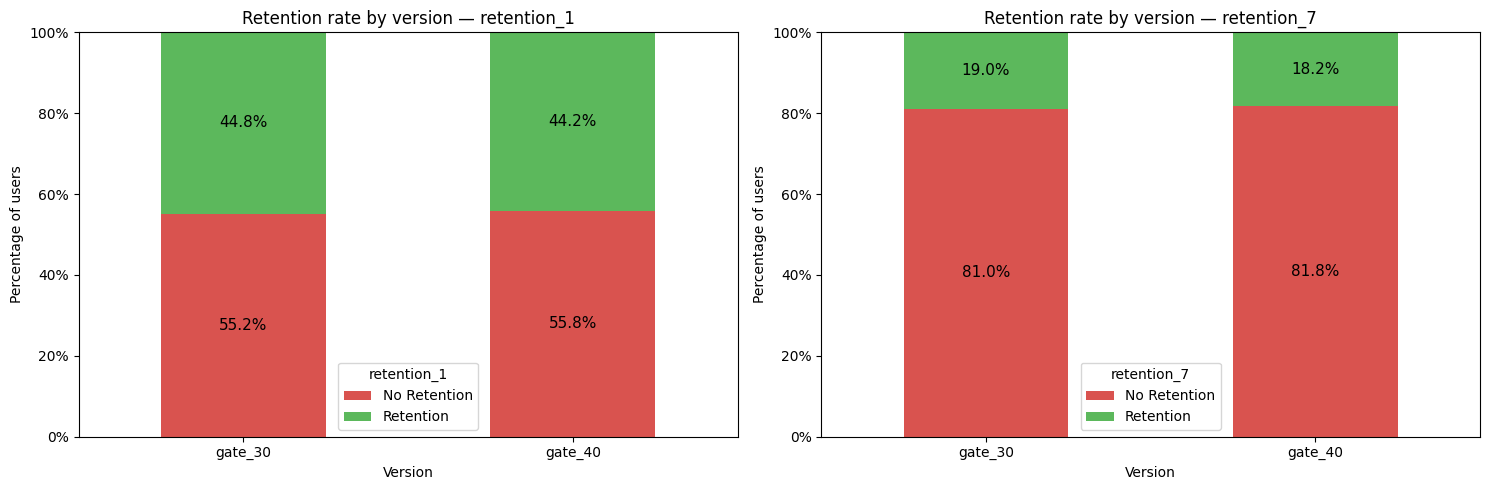

In [61]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

for i, col in enumerate(["retention_1", "retention_7"]):
    proportions = (
        data.groupby("version")[col]
        .value_counts(normalize = True)
        .unstack()
        .rename(columns={0: "No Retention", 1: "Retention"})
    )
    proportions.plot(kind = "bar", stacked = True, ax = axes[i], color = ["#d9534f", "#5cb85c"])

    for container in axes[i].containers:
        labels = [f"{v:.1%}" for v in container.datavalues]
        axes[i].bar_label(container, labels = labels, label_type = "center", fontsize = 11)

    axes[i].set_title(f"Retention rate by version — {col}")
    axes[i].set_xlabel("Version")
    axes[i].set_ylabel("Percentage of users")
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax = 1))
    axes[i].tick_params(axis = "x", rotation = 0)
    axes[i].legend(title = col)

plt.tight_layout()
plt.show()

Two patterns stand out.
- First, retention drops sharply between day 1 and day 7 across both groups. Big proportion of players who return on day 1 are gone by day 7.
- Second, `gate_40` shows slightly lower retention in both timeframes, with the gap appearing slightly more pronounced at 7 days. Whether this difference is statistically meaningful or just noise is what the tests below will determine.

### 2.2. Game rounds

In [29]:
data.groupby(["version"])[["sum_gamerounds"]].describe()

sum_gamerounds                                                     
                 count       mean         std  min  25%   50%   75%     max
version                                                                    
gate_30        44699.0  51.342111  102.057598  0.0  5.0  17.0  50.0  2961.0
gate_40        45489.0  51.298776  103.294416  0.0  5.0  16.0  52.0  2640.0

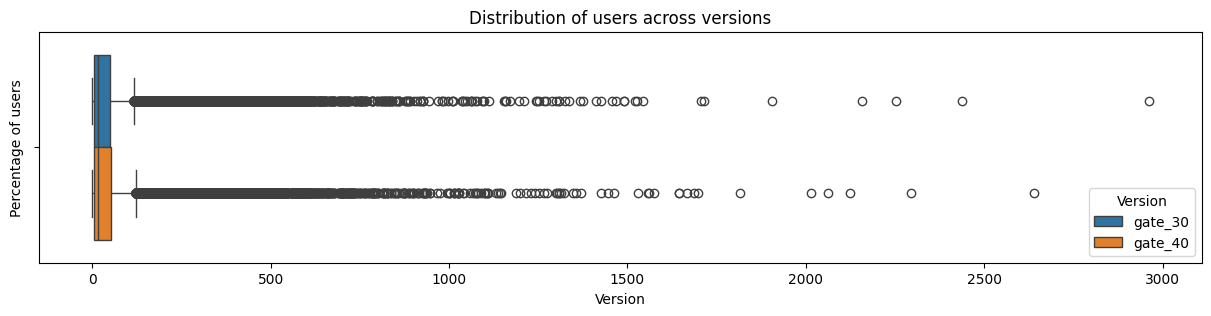

In [30]:
plt.figure(figsize = (15, 3))
sns.boxplot(data = data[data["sum_gamerounds"] < 10000], x = "sum_gamerounds", hue = "version")
plt.title("Distribution of users across versions")
plt.xlabel("Version")
plt.ylabel("Percentage of users")
plt.legend(title = "Version")
plt.show()

The heavy right tail makes the boxplot largely uninformative — both distributions are visually indistinguishable at this scale. The summary statistics tell the same story: means (~51 rounds), standard deviations (~102), and all quartiles are nearly identical between `gate_30` and `gate_40`. There is no visible engagement difference driven by the gate placement.

## 3. Statistical tests

In [38]:
for col in ["retention_1", "retention_7"]:
    counts = data.groupby("version")[col].value_counts().unstack()
    group_a = counts.index[0]
    z_stat, p_value = proportions_ztest(counts[1], counts.sum(axis = 1))
    print(f"Z-test for {col}: z-statistic = {z_stat:.4f}, p-value = {p_value:.4f}."
          f" Group A: {group_a}")

Z-test for retention_1: z-statistic = 1.7871, p-value = 0.0739. Group A: gate_30
Z-test for retention_7: z-statistic = 3.1574, p-value = 0.0016. Group A: gate_30


**1-day retention (not significant, p=0.07):** two factors explain the lack of signal. First, many players haven't reached level 30 or 40 within the first day, so the gate hasn't activated for a large share of the sample — the treatment simply hasn't had a chance to produce an effect. Second, casual users who download the game out of curiosity and churn within hours regardless of gate placement add noise that dilutes any real difference.

**7-day retention (significant, p=0.002, gate_30 higher):** gate_30 outperforms gate_40 in long-term retention. The likely mechanism is that hitting a gate at level 30 creates a forced pause *earlier*, before fatigue has accumulated. This acts as a natural circuit breaker that resets engagement and builds anticipation to return. Players in gate_40 grind through more levels before reaching that break, so when they stop it feels more like exhaustion than a cliffhanger, making them less likely to come back.

Observed difference: 0.04333503360787461
Confidence interval: [-1.275, 1.3751]
P-value: 0.9509


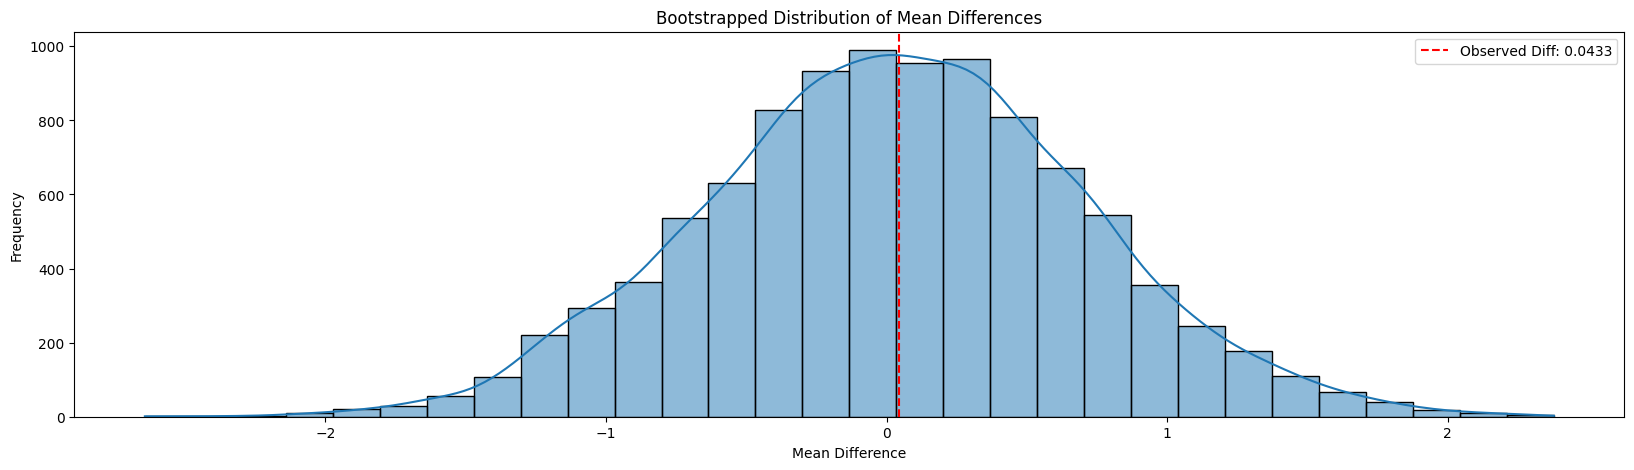

In [ ]:
class ABTest:
    def __init__(self, data, group_col, value_col):
        group_values = data[group_col].unique()
        if len(group_values) != 2:
            raise ValueError("Exactly two groups are required.")
        self.group_col = group_col
        self.value_col = value_col
        self.group1 = data[data[group_col] == group_values[0]][value_col].values
        self.group2 = data[data[group_col] == group_values[1]][value_col].values
        self.observed_diff = self.group1.mean() - self.group2.mean()

    def permutation_test(self, n_permutations = 10000):
        combined = np.concatenate([self.group1, self.group2])
        perm_diffs = []
        for _ in range(n_permutations):
            np.random.shuffle(combined)
            perm_diffs.append(combined[:len(self.group1)].mean() - combined[len(self.group1):].mean())
        return np.mean(np.abs(perm_diffs) >= np.abs(self.observed_diff))

    def bootstrap_ci(self, n_bootstrap = 10000, confidence_level = 0.95):
        bootstrap_diffs = [
            np.random.choice(self.group1, size=len(self.group1), replace=True).mean()
            - np.random.choice(self.group2, size=len(self.group2), replace=True).mean()
            for _ in range(n_bootstrap)
        ]
        lower = np.percentile(bootstrap_diffs, (1 - confidence_level) / 2 * 100)
        upper = np.percentile(bootstrap_diffs, (1 + confidence_level) / 2 * 100)
        return lower, upper, bootstrap_diffs

    def visualize_bootstrap_distribution(self, bootstrap_diffs):
        plt.figure(figsize=(20, 5))
        sns.histplot(bootstrap_diffs, bins=30, kde=True)
        plt.axvline(self.observed_diff, color='red', linestyle='--',
                    label=f'Observed Diff: {self.observed_diff:.4f}')
        plt.title("Bootstrapped Distribution of Mean Differences")
        plt.xlabel("Mean Difference")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

    def run(self, n_permutations = 10000, n_bootstrap = 10000, confidence_level = 0.95):
        p_value = self.permutation_test(n_permutations)
        lower, upper, bootstrap_diffs = self.bootstrap_ci(n_bootstrap, confidence_level)
        print(f"Observed difference: {self.observed_diff}")
        print(f"Confidence interval: {[round(float(lower), 4), round(float(upper), 4)]}")
        print(f"P-value: {p_value}")
        self.visualize_bootstrap_distribution(bootstrap_diffs)


ab_gr = ABTest(data, "version", "sum_gamerounds")
ab_gr.run()

A standard z-test is not appropriate for `sum_gamerounds` given its heavy right skew (the normality assumption would be violated). Instead, a permutation test is used to assess significance (by checking how often a random reshuffling of group labels produces a difference as large as the observed one), and bootstrapping to estimate the 95% confidence interval around the mean difference.

Both confirm what the descriptive stats already suggested: the difference between `gate_30` and `gate_40` in game rounds is not statistically significant, and the confidence interval straddles zero. The gate placement has no detectable effect on raw engagement volume.

## 4. Conclusions

**Retention-focused approach:** the evidence supports keeping the gate at level 30. 7-day retention is significantly higher for `gate_30`, suggesting that an earlier forced pause prevents burnout and keeps players coming back. The guardrail metric — game rounds — is unaffected by the gate placement, meaning the improvement in retention comes at no cost to engagement volume.

**Monetization-focused approach:** gate placement has no significant effect on game rounds, so neither version produces more playtime or ad impressions than the other in the short term. However, since `gate_30` yields better long-term retention, it is also the better choice under this framing: more players returning over time translates to more cumulative ad revenue than a short burst of playtime followed by higher churn.

**Overall recommendation:** move forward with `gate_30`. It wins on the primary retention metric, has no downside on engagement, and is the dominant option even under a monetization lens.

## Bonus

### 1. Estimating Minimum Detectable Effect (MDE) empirically

The **MDE** is the smallest true effect size that the experiment can reliably detect, given the current sample size, data variance, significance level α, and desired statistical power 1 − β.

#### Why calculate it here?

The observed difference in `sum_gamerounds` between `gate_30` and `gate_40` is ~0.01% of the control mean — essentially zero. Before concluding that game rounds are insensitive to the gate change, it is worth asking: *how large would the effect have to be for this test to detect it at all?* If the MDE turns out to be very large (e.g. >20%), it means the experiment is underpowered for this metric and a non-significant result carries little weight.

#### Approach: empirical bisection + normal-theory power correction

The closed-form MDE formula is:

$$\text{MDE} = (Z_{\alpha/2} + Z_{\beta}) \cdot \sigma \cdot \sqrt{\frac{2}{n}}$$

This assumes normality. `sum_gamerounds` is heavily right-skewed, so instead a two-step empirical approach is used.

**Step 1 — Bisection search via permutation test**

A synthetic treatment group is created by multiplying all control values by $1 + \delta / 100$ (a $\delta\%$ proportional lift). A permutation test is then run on the resulting data. Binary search over $\delta$ finds the smallest lift that makes the test reject $H_0$ at $\alpha = 0.05$.

It converges to the boundary between detectable / not detectable, where statistical power $\approx 50\%$: the test rejects about half the time when the true effect equals the MDE. This is the *significance-only* MDE, written $\text{MDE}_{\alpha}$.

**Step 2 — Power adjustment via normal approximation**

To rescale from ~50% power to a target power (80%), the following ratio from normal theory is applied:

$$\text{MDE}_{1-\beta} = \frac{Z_{\alpha/2} + Z_{\beta}}{Z_{\alpha/2}} \times \text{MDE}_{\alpha}$$

With $\alpha = 0.05$ and $1 - \beta = 0.80$: $Z_{\alpha/2} = 1.96$, $Z_\beta = 0.842$, scale factor $\approx 1.43$.

#### Why this tradeoff?

The fully empirical alternative would be to run ~1 000 simulations per candidate $\delta$ and define the MDE as the smallest $\delta$ where >80% of them reject $H_0$. This answers the question: if we ran this experiment 1000 times drawing different users each time, how often would we detect a true effect of size $\delta$?. Their rejection rate is a direct, assumption-free estimate of power. The cost is roughly 1 000× more computation.

The chosen approach instead runs a single permutation test per $\delta$ and corrects the resulting 50% power MDE analytically. The normal approximation is only applied at the power-scaling step, where distributional sensitivity is lower than in the bisection itself. This is a pragmatic and standard compromise.

In [59]:
def get_empirical_mde(data: pd.DataFrame, group_col: str, ctrl_value: str, value_col: str,
                      max_iterations: int = 10, lower_bound: float = 1, upper_bound: float = 10,
                      alpha: float = 0.05, power: float = 0.8):
    control = data[data[group_col] == ctrl_value].copy()
    positive_direction = lower_bound > 0
    results = []

    for _ in range(max_iterations):
        selected_mde = (lower_bound + upper_bound) / 2
        treatment = control.assign(
            **{value_col: control[value_col] * (1 + selected_mde / 100), group_col: "treatment"}
        )
        p_value = ABTest(pd.concat([control, treatment], ignore_index = True), group_col,
                         value_col).permutation_test()
        results.append((selected_mde, p_value))

        if (p_value < alpha) == positive_direction:
            upper_bound = selected_mde
        else:
            lower_bound = selected_mde

    scale = (norm.ppf(1 - alpha / 2) + norm.ppf(power)) / norm.ppf(1 - alpha / 2)
    df = pd.DataFrame(results, columns=["mde", "p_value"])
    df["adjusted_mde"] = df["mde"] * scale
    return df

mde_results = get_empirical_mde(data, "version", "gate_30", "sum_gamerounds")

#### Interpretation

The MDE (~3.8%) means the experiment would need a true lift of at least ~3.8% in mean game rounds to detect it with 80% power at α = 0.05. The observed difference (~0.08%) is roughly 50× smaller than the MDE, confirming that game rounds are not a sensitive metric for this experiment — not because there is no effect, but because the effect (if any) is far below what this sample size can reliably detect.

In [63]:
print("Observed difference as percentage of control mean: "
      f"{ab_gr.observed_diff / data[data['version'] == 'gate_30']\
         ['sum_gamerounds'].mean() * 100:.2f}%")
print(f"Minimum detectable effect (MDE) at 5% significance level:"
      f" {mde_results[mde_results['p_value'] < 0.05]['adjusted_mde'].min():.2f}%")

Observed difference as percentage of control mean: 0.08%
Minimum detectable effect (MDE) at 5% significance level: 3.79%
